# RT-DETR Model Comparison on DAWN

This notebook compares the following saved checkpoints on the full DAWN dataset:

- `rtdetrv2_finetuned_100`
- `rtdetrv2_finetuned_75`
- `rtdetrv2_finetuned_50`
- `rtdetrv2_finetuned_25`
- `rtdetr_finetuned_100`

Reported metrics:

- **Accuracy**: $\frac{TP}{TP + FP + FN}$ at IoU $=0.50$
- **Precision** at IoU $=0.50$
- **Recall** at IoU $=0.50$
- **mAP50**
- **mAP50-95**

The notebook also generates summary plots and qualitative prediction visualizations for all models.

In [1]:
from pathlib import Path
from collections import defaultdict
import json
import gc
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import kagglehub
import torch
from transformers import AutoImageProcessor, RTDetrForObjectDetection, RTDetrV2ForObjectDetection
from torchmetrics.detection.mean_ap import MeanAveragePrecision

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)

PROJECT_ROOT = Path.cwd()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4 if DEVICE.type == "cuda" else 2
SCORE_THRESHOLD = 0.30
MATCH_IOU = 0.50

MODEL_DIRS = {
    "rtdetrv2_finetuned_100": PROJECT_ROOT / "rtdetrv2_finetuned_100",
    "rtdetrv2_finetuned_75": PROJECT_ROOT / "rtdetrv2_finetuned_75",
    "rtdetrv2_finetuned_50": PROJECT_ROOT / "rtdetrv2_finetuned_50",
    "rtdetrv2_finetuned_25": PROJECT_ROOT / "rtdetrv2_finetuned_25",
    "rtdetr_finetuned_100": PROJECT_ROOT / "rtdetr_finetuned_100",
}

missing_models = [name for name, path in MODEL_DIRS.items() if not path.exists()]
if missing_models:
    raise FileNotFoundError(f"Missing model folders: {missing_models}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE} | Batch size: {BATCH_SIZE}")
print("Models to compare:")
for name, path in MODEL_DIRS.items():
    print(f"  - {name}: {path}")

f:\repos\COMP9130proj\COMP9130_Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: f:\repos\COMP9130proj\COMP9130_Final
Device: cuda | Batch size: 4
Models to compare:
  - rtdetrv2_finetuned_100: f:\repos\COMP9130proj\COMP9130_Final\rtdetrv2_finetuned_100
  - rtdetrv2_finetuned_75: f:\repos\COMP9130proj\COMP9130_Final\rtdetrv2_finetuned_75
  - rtdetrv2_finetuned_50: f:\repos\COMP9130proj\COMP9130_Final\rtdetrv2_finetuned_50
  - rtdetrv2_finetuned_25: f:\repos\COMP9130proj\COMP9130_Final\rtdetrv2_finetuned_25
  - rtdetr_finetuned_100: f:\repos\COMP9130proj\COMP9130_Final\rtdetr_finetuned_100


In [7]:
COCO_NAME_MAP = {
    0: "person",
    1: "bicycle",
    2: "car",
    3: "motorbike",
    5: "bus",
    7: "truck",
}


def get_weather(file_name: str) -> str:
    name = file_name.lower()
    if "snow" in name:
        return "snow"
    if "rain" in name or "mist" in name:
        return "rain"
    if "fog" in name or "haze" in name:
        return "fog"
    if "sand" in name or "dust" in name:
        return "sand"
    return "other"


def infer_class_mapping(label_paths, sample_limit=200):
    observed = set()
    checked = 0
    for label_path in label_paths:
        if label_path is None:
            continue
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    observed.add(int(float(parts[0])))
        checked += 1
        if checked >= sample_limit:
            break

    if not observed:
        return {}, "no-labels", observed

    if observed.issubset({1, 2, 3, 4, 6, 8}):
        mapping = {1: 0, 2: 1, 3: 2, 4: 3, 6: 5, 8: 7}
        mode = "original_coco_1based"
    elif observed.issubset({0, 1, 2, 3, 5, 7}):
        mapping = {0: 0, 1: 1, 2: 2, 3: 3, 5: 5, 7: 7}
        mode = "coco_0based"
    elif observed.issubset({0, 1, 2, 3, 4, 5}):
        mapping = {0: 0, 1: 1, 2: 2, 3: 3, 4: 5, 5: 7}
        mode = "compact_6class"
    else:
        mapping = {k: k for k in observed}
        mode = "identity"

    return mapping, mode, observed


def load_dawn_samples():
    dataset_root = Path(kagglehub.dataset_download("shuvoalok/dawn-dataset"))
    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    image_paths = sorted([p for p in dataset_root.rglob("*") if p.suffix.lower() in image_exts])
    label_paths = sorted(dataset_root.rglob("*.txt"))
    labels_by_stem = {p.stem: p for p in label_paths}

    class_mapping, mapping_mode, observed_ids = infer_class_mapping(label_paths)

    samples = []
    for image_path in image_paths:
        samples.append({
            "file_name": image_path.name,
            "image_path": image_path,
            "label_path": labels_by_stem.get(image_path.stem),
            "weather": get_weather(image_path.name),
        })

    return dataset_root, samples, class_mapping, mapping_mode, observed_ids

# flip horizontal for all images in list
flip_list = [
    "dusttornado-038.jpg",
    "dusttornado-909.jpg",
    "dusttornado-937.jpg",
    "rain_storm-901.jpg",
    "rain_storm-932.jpg",
    "rain_storm-939.jpg",
    "rain_storm-985.jpg",
    "sand_storm_g2_-026.jpg",
    "sand_storm_g2_-029.jpg",
    "sand_storm_g2_-063.jpg",
    "sand_storm_g2_-068.jpg",
    "sand_storm_g2_-079.jpg",
    "sand_storm-042.jpg",
    "sand_storm-077.jpg",
    "sand_storm-100.jpg",
    "sand_storm-103.jpg",
    "sand_storm-114.jpg",
    "sand_storm-129.jpg",
    "sand_storm-133.jpg",
    "sand_storm-138.jpg",
    "sand_storm-145.jpg",
    "sand_storm-157.jpg",
    "sand_storm-164.jpg",
    "sand_storm-165.jpg",
    "sand_storm-236.jpg",
    "sand_storm-246.jpg",
    "sand_storm-348.jpg",
    "sand_storm-359.jpg",
    "sand_storm-901.jpg",
    "sand_storm-910.jpg",
    "sand_storm-911.jpg",
    "sand_storm-913.jpg",
    "sand_storm-923.jpg",
    "sand_storm-924.jpg",
    "sand_storm-928.jpg",
    "sand_storm-940.jpg",
    "sand_storm-953.jpg",
    "sand_storm-989.jpg",
    "sand_storm-999.jpg"
]
FLIP_SET = set(flip_list)


def parse_yolo_target(label_path, image_size, class_mapping, image_name=None):
    width, height = image_size
    boxes = []
    labels = []

    if image_name is None and label_path is not None:
        image_name = f"{Path(label_path).stem}.jpg"

    if label_path is None or not Path(label_path).exists():
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64),
        }

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            raw_cls = int(float(parts[0]))
            cls_id = class_mapping.get(raw_cls, raw_cls)
            cx, cy, bw, bh = map(float, parts[1:5])

            x1 = max(0.0, (cx - bw / 2) * width)
            y1 = max(0.0, (cy - bh / 2) * height)
            x2 = min(width, (cx + bw / 2) * width)
            y2 = min(height, (cy + bh / 2) * height)

            if image_name in FLIP_SET:
                x1, x2 = width - x2, width - x1

            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(cls_id)

    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
    }


def choose_visual_samples(samples, max_samples=4):
    selected = []
    seen = set()

    for weather in ["fog", "rain", "snow", "sand", "other"]:
        for sample in samples:
            if sample["weather"] == weather and sample["file_name"] not in seen:
                selected.append(sample)
                seen.add(sample["file_name"])
                break
        if len(selected) >= max_samples:
            break

    if len(selected) < max_samples:
        for sample in samples:
            if sample["file_name"] not in seen:
                selected.append(sample)
                seen.add(sample["file_name"])
            if len(selected) >= max_samples:
                break

    return selected


dataset_root, dawn_samples, CLASS_MAPPING, MAPPING_MODE, OBSERVED_IDS = load_dawn_samples()
VISUAL_SAMPLES = choose_visual_samples(dawn_samples, max_samples=4)

print(f"Dataset root: {dataset_root}")
print(f"Images found: {len(dawn_samples)}")
print(f"Label mapping mode: {MAPPING_MODE}")
print(f"Observed class IDs: {sorted(list(OBSERVED_IDS))}")
display(pd.DataFrame(dawn_samples)[["file_name", "weather", "label_path"]].head())

Dataset root: C:\Users\mwper\.cache\kagglehub\datasets\shuvoalok\dawn-dataset\versions\5
Images found: 1005
Label mapping mode: original_coco_1based
Observed class IDs: [1, 2, 3, 4, 6, 8]


,file_name,weather,label_path
0,dusttornado-001.jpg,sand,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
1,dusttornado-002.jpg,sand,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
2,dusttornado-003.jpg,sand,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
3,dusttornado-004.jpg,sand,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
4,dusttornado-005.jpg,sand,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...


In [9]:
flip_sample = next((s for s in dawn_samples if s["file_name"] in FLIP_SET and s["label_path"] is not None), None)

if flip_sample is None:
    print("No flip-list sample was found for verification.")
else:
    verify_image = Image.open(flip_sample["image_path"]).convert("RGB")
    width, height = verify_image.size

    with open(flip_sample["label_path"], "r") as f:
        first_line = next((line for line in f if line.strip()), None)

    if first_line is None:
        print(f"No annotations found in {flip_sample['file_name']}")
    else:
        _, cx, cy, bw, bh = map(float, first_line.strip().split()[:5])
        original_x1 = max(0.0, (cx - bw / 2) * width)
        original_x2 = min(width, (cx + bw / 2) * width)

        parsed_target = parse_yolo_target(
            flip_sample["label_path"],
            verify_image.size,
            CLASS_MAPPING,
            image_name=flip_sample["file_name"],
        )
        flipped_x1, _, flipped_x2, _ = parsed_target["boxes"][0].tolist()

        print(f"Verification sample: {flip_sample['file_name']}")
        print(f"Original x-range: ({original_x1:.1f}, {original_x2:.1f})")
        print(f"Flipped  x-range: ({flipped_x1:.1f}, {flipped_x2:.1f})")

Verification sample: dusttornado-038.jpg
Original x-range: (746.0, 826.0)
Flipped  x-range: (166.0, 246.0)


In [8]:
def to_float(value):
    return float(value.item()) if hasattr(value, "item") else float(value)


def box_iou_xyxy(boxes1, boxes2):
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    top_left = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    bottom_right = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (bottom_right - top_left).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]
    union = area1[:, None] + area2 - inter
    return inter / union.clamp(min=1e-9)


def greedy_detection_counts(pred, target, score_thr=SCORE_THRESHOLD, iou_thr=MATCH_IOU):
    score_mask = pred["scores"] >= score_thr
    pred_boxes = pred["boxes"][score_mask]
    pred_scores = pred["scores"][score_mask]
    pred_labels = pred["labels"][score_mask]

    gt_boxes = target["boxes"]
    gt_labels = target["labels"]

    if len(gt_boxes) == 0 and len(pred_boxes) == 0:
        return 0, 0, 0
    if len(gt_boxes) == 0:
        return 0, int(len(pred_boxes)), 0
    if len(pred_boxes) == 0:
        return 0, 0, int(len(gt_boxes))

    order = torch.argsort(pred_scores, descending=True)
    matched_gt = set()
    tp = 0
    fp = 0

    for pred_idx in order.tolist():
        same_class = torch.where(gt_labels == pred_labels[pred_idx])[0]
        if len(same_class) == 0:
            fp += 1
            continue

        ious = box_iou_xyxy(pred_boxes[pred_idx:pred_idx + 1], gt_boxes[same_class])[0]
        best_iou, best_local_idx = torch.max(ious, dim=0)
        best_gt_idx = int(same_class[int(best_local_idx)].item())

        if best_iou.item() >= iou_thr and best_gt_idx not in matched_gt:
            matched_gt.add(best_gt_idx)
            tp += 1
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return int(tp), int(fp), int(fn)


def load_model_bundle(model_dir: Path):
    with open(model_dir / "config.json", "r") as f:
        config = json.load(f)

    arch = config.get("architectures", ["RTDetrV2ForObjectDetection"])[0]
    model_cls = RTDetrForObjectDetection if arch == "RTDetrForObjectDetection" else RTDetrV2ForObjectDetection

    processor = AutoImageProcessor.from_pretrained(model_dir)
    model = model_cls.from_pretrained(model_dir).to(DEVICE).eval()
    return processor, model, arch


def evaluate_model(model_name, model_dir, samples, visual_samples, batch_size=BATCH_SIZE):
    processor, model, arch = load_model_bundle(model_dir)
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    total_tp = total_fp = total_fn = 0
    weather_counts = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0})
    visual_predictions = {}
    visual_names = {sample["file_name"] for sample in visual_samples}

    for start in tqdm(range(0, len(samples), batch_size), desc=f"Evaluating {model_name}"):
        batch = samples[start:start + batch_size]
        pil_images = [Image.open(item["image_path"]).convert("RGB") for item in batch]
        targets = [
            parse_yolo_target(item["label_path"], image.size, CLASS_MAPPING, image_name=item["file_name"])
            for item, image in zip(batch, pil_images)
        ]

        inputs = processor(images=pil_images, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([(img.size[1], img.size[0]) for img in pil_images], device=DEVICE)
        processed = processor.post_process_object_detection(outputs, threshold=0.001, target_sizes=target_sizes)

        for item, pred_raw, target in zip(batch, processed, targets):
            pred = {
                "boxes": pred_raw["boxes"].detach().cpu(),
                "scores": pred_raw["scores"].detach().cpu(),
                "labels": pred_raw["labels"].detach().cpu(),
            }

            metric.update([pred], [target])
            tp, fp, fn = greedy_detection_counts(pred, target)
            total_tp += tp
            total_fp += fp
            total_fn += fn

            weather_counts[item["weather"]]["tp"] += tp
            weather_counts[item["weather"]]["fp"] += fp
            weather_counts[item["weather"]]["fn"] += fn

            if item["file_name"] in visual_names:
                visual_predictions[item["file_name"]] = pred

    metric_result = metric.compute()
    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)
    accuracy = total_tp / (total_tp + total_fp + total_fn + 1e-9)

    summary = {
        "model": model_name,
        "architecture": arch.replace("ForObjectDetection", ""),
        "images": len(samples),
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "mAP50": to_float(metric_result["map_50"]),
        "mAP50-95": to_float(metric_result["map"]),
    }

    weather_rows = []
    for weather, counts in weather_counts.items():
        w_tp, w_fp, w_fn = counts["tp"], counts["fp"], counts["fn"]
        w_precision = w_tp / (w_tp + w_fp + 1e-9)
        w_recall = w_tp / (w_tp + w_fn + 1e-9)
        w_accuracy = w_tp / (w_tp + w_fp + w_fn + 1e-9)
        w_f1 = 2 * w_precision * w_recall / (w_precision + w_recall + 1e-9)
        weather_rows.append({
            "model": model_name,
            "weather": weather,
            "accuracy": w_accuracy,
            "precision": w_precision,
            "recall": w_recall,
            "f1": w_f1,
            "tp": w_tp,
            "fp": w_fp,
            "fn": w_fn,
        })

    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return summary, pd.DataFrame(weather_rows), visual_predictions

In [10]:
results = []
weather_tables = []
all_visual_predictions = {}

for model_name, model_dir in MODEL_DIRS.items():
    summary, weather_df_model, visual_preds = evaluate_model(
        model_name=model_name,
        model_dir=model_dir,
        samples=dawn_samples,
        visual_samples=VISUAL_SAMPLES,
        batch_size=BATCH_SIZE,
    )
    results.append(summary)
    weather_tables.append(weather_df_model)
    all_visual_predictions[model_name] = visual_preds

results_df = pd.DataFrame(results).sort_values(["mAP50-95", "mAP50"], ascending=False).reset_index(drop=True)
weather_df = pd.concat(weather_tables, ignore_index=True).sort_values(["weather", "model"]).reset_index(drop=True)

results_dir = PROJECT_ROOT / "results" / "rtdetr_comparison"
results_dir.mkdir(parents=True, exist_ok=True)
results_df.to_csv(results_dir / "model_comparison_metrics.csv", index=False)
weather_df.to_csv(results_dir / "weather_breakdown.csv", index=False)

print(f"Saved summary CSV to: {results_dir / 'model_comparison_metrics.csv'}")
print(f"Saved weather CSV to: {results_dir / 'weather_breakdown.csv'}")
display(results_df.round(4))
display(weather_df.round(4).head(20))

Evaluating rtdetrv2_finetuned_100:   0%|          | 0/252 [00:00<?, ?it/s]f:\repos\COMP9130proj\COMP9130_Final\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Evaluating rtdetr_finetuned_100: 100%|██████████| 252/252 [00:22<00:00, 11.33it/s]


Saved summary CSV to: f:\repos\COMP9130proj\COMP9130_Final\results\rtdetr_comparison\model_comparison_metrics.csv
Saved weather CSV to: f:\repos\COMP9130proj\COMP9130_Final\results\rtdetr_comparison\weather_breakdown.csv


,model,architecture,images,tp,fp,fn,accuracy,precision,recall,mAP50,mAP50-95
0,rtdetrv2_finetuned_100,RTDetrV2,1005,6029,106,1721,0.7674,0.9827,0.7779,0.9116,0.7084
1,rtdetr_finetuned_100,RTDetr,1005,5845,103,1905,0.7443,0.9827,0.7542,0.8866,0.6851
2,rtdetrv2_finetuned_75,RTDetrV2,1005,5963,169,1787,0.7530,0.9724,0.7694,0.8754,0.6628
3,rtdetrv2_finetuned_50,RTDetrV2,1005,6037,386,1713,0.7420,0.9399,0.7790,0.7705,0.5529
4,rtdetrv2_finetuned_25,RTDetrV2,1005,6017,624,1733,0.7185,0.9060,0.7764,0.7509,0.5038


,model,weather,accuracy,precision,recall,f1,tp,fp,fn
0,rtdetr_finetuned_100,fog,0.7904,0.9675,0.8120,0.8829,924,31,214
1,rtdetrv2_finetuned_100,fog,0.8094,0.9722,0.8286,0.8947,943,27,195
2,rtdetrv2_finetuned_25,fog,0.7280,0.8993,0.7926,0.8426,902,101,236
3,rtdetrv2_finetuned_50,fog,0.7781,0.9351,0.8225,0.8752,936,65,202
4,rtdetrv2_finetuned_75,fog,0.8169,0.9686,0.8392,0.8992,955,31,183
5,rtdetr_finetuned_100,rain,0.7505,0.9883,0.7573,0.8575,1772,21,568
6,rtdetrv2_finetuned_100,rain,0.7843,0.9872,0.7923,0.8791,1854,24,486
7,rtdetrv2_finetuned_25,rain,0.7560,0.9006,0.8248,0.8610,1930,213,410
8,rtdetrv2_finetuned_50,rain,0.7614,0.9452,0.7966,0.8646,1864,108,476
9,rtdetrv2_finetuned_75,rain,0.7628,0.9774,0.7765,0.8654,1817,42,523


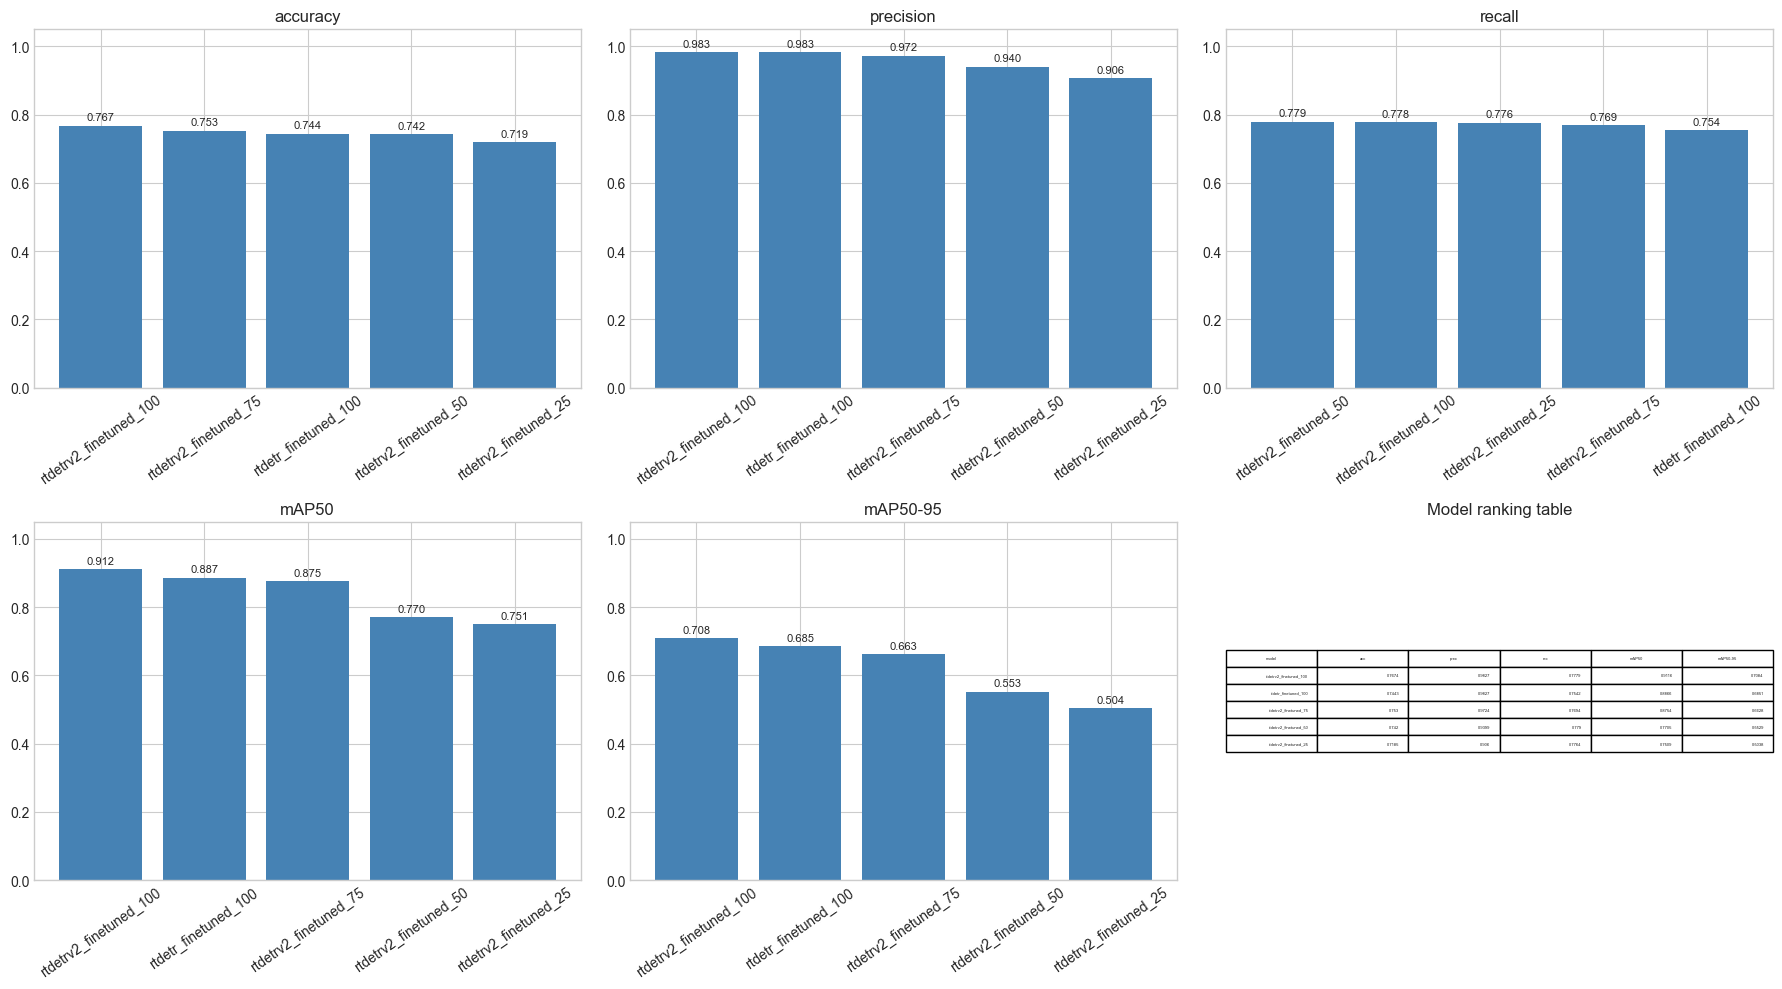

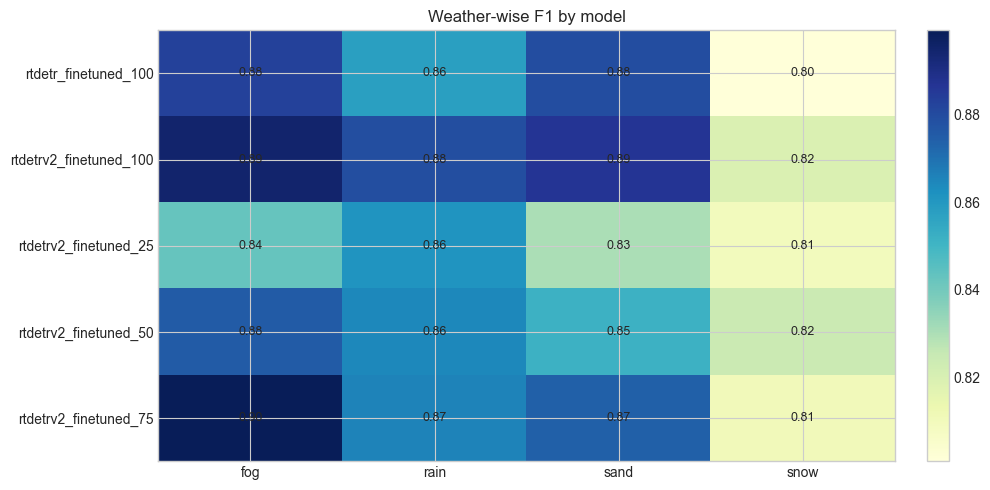

In [11]:
metric_cols = ["accuracy", "precision", "recall", "mAP50", "mAP50-95"]
plot_df = results_df.copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metric_cols):
    ordered = plot_df.sort_values(metric, ascending=False)
    bars = ax.bar(ordered["model"], ordered[metric], color="steelblue")
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=35)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

rank_metric = "mAP50-95"
ordered = plot_df.sort_values(rank_metric, ascending=False)
axes[-1].axis("off")
axes[-1].table(
    cellText=ordered[["model", "accuracy", "precision", "recall", "mAP50", "mAP50-95"]].round(4).values,
    colLabels=["model", "acc", "prec", "rec", "mAP50", "mAP50-95"],
    loc="center",
)
axes[-1].set_title("Model ranking table")

plt.tight_layout()
plt.show()

weather_pivot = weather_df.pivot(index="model", columns="weather", values="f1").fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(weather_pivot.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(weather_pivot.columns)))
ax.set_xticklabels(weather_pivot.columns)
ax.set_yticks(range(len(weather_pivot.index)))
ax.set_yticklabels(weather_pivot.index)
ax.set_title("Weather-wise F1 by model")
for i in range(weather_pivot.shape[0]):
    for j in range(weather_pivot.shape[1]):
        ax.text(j, i, f"{weather_pivot.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

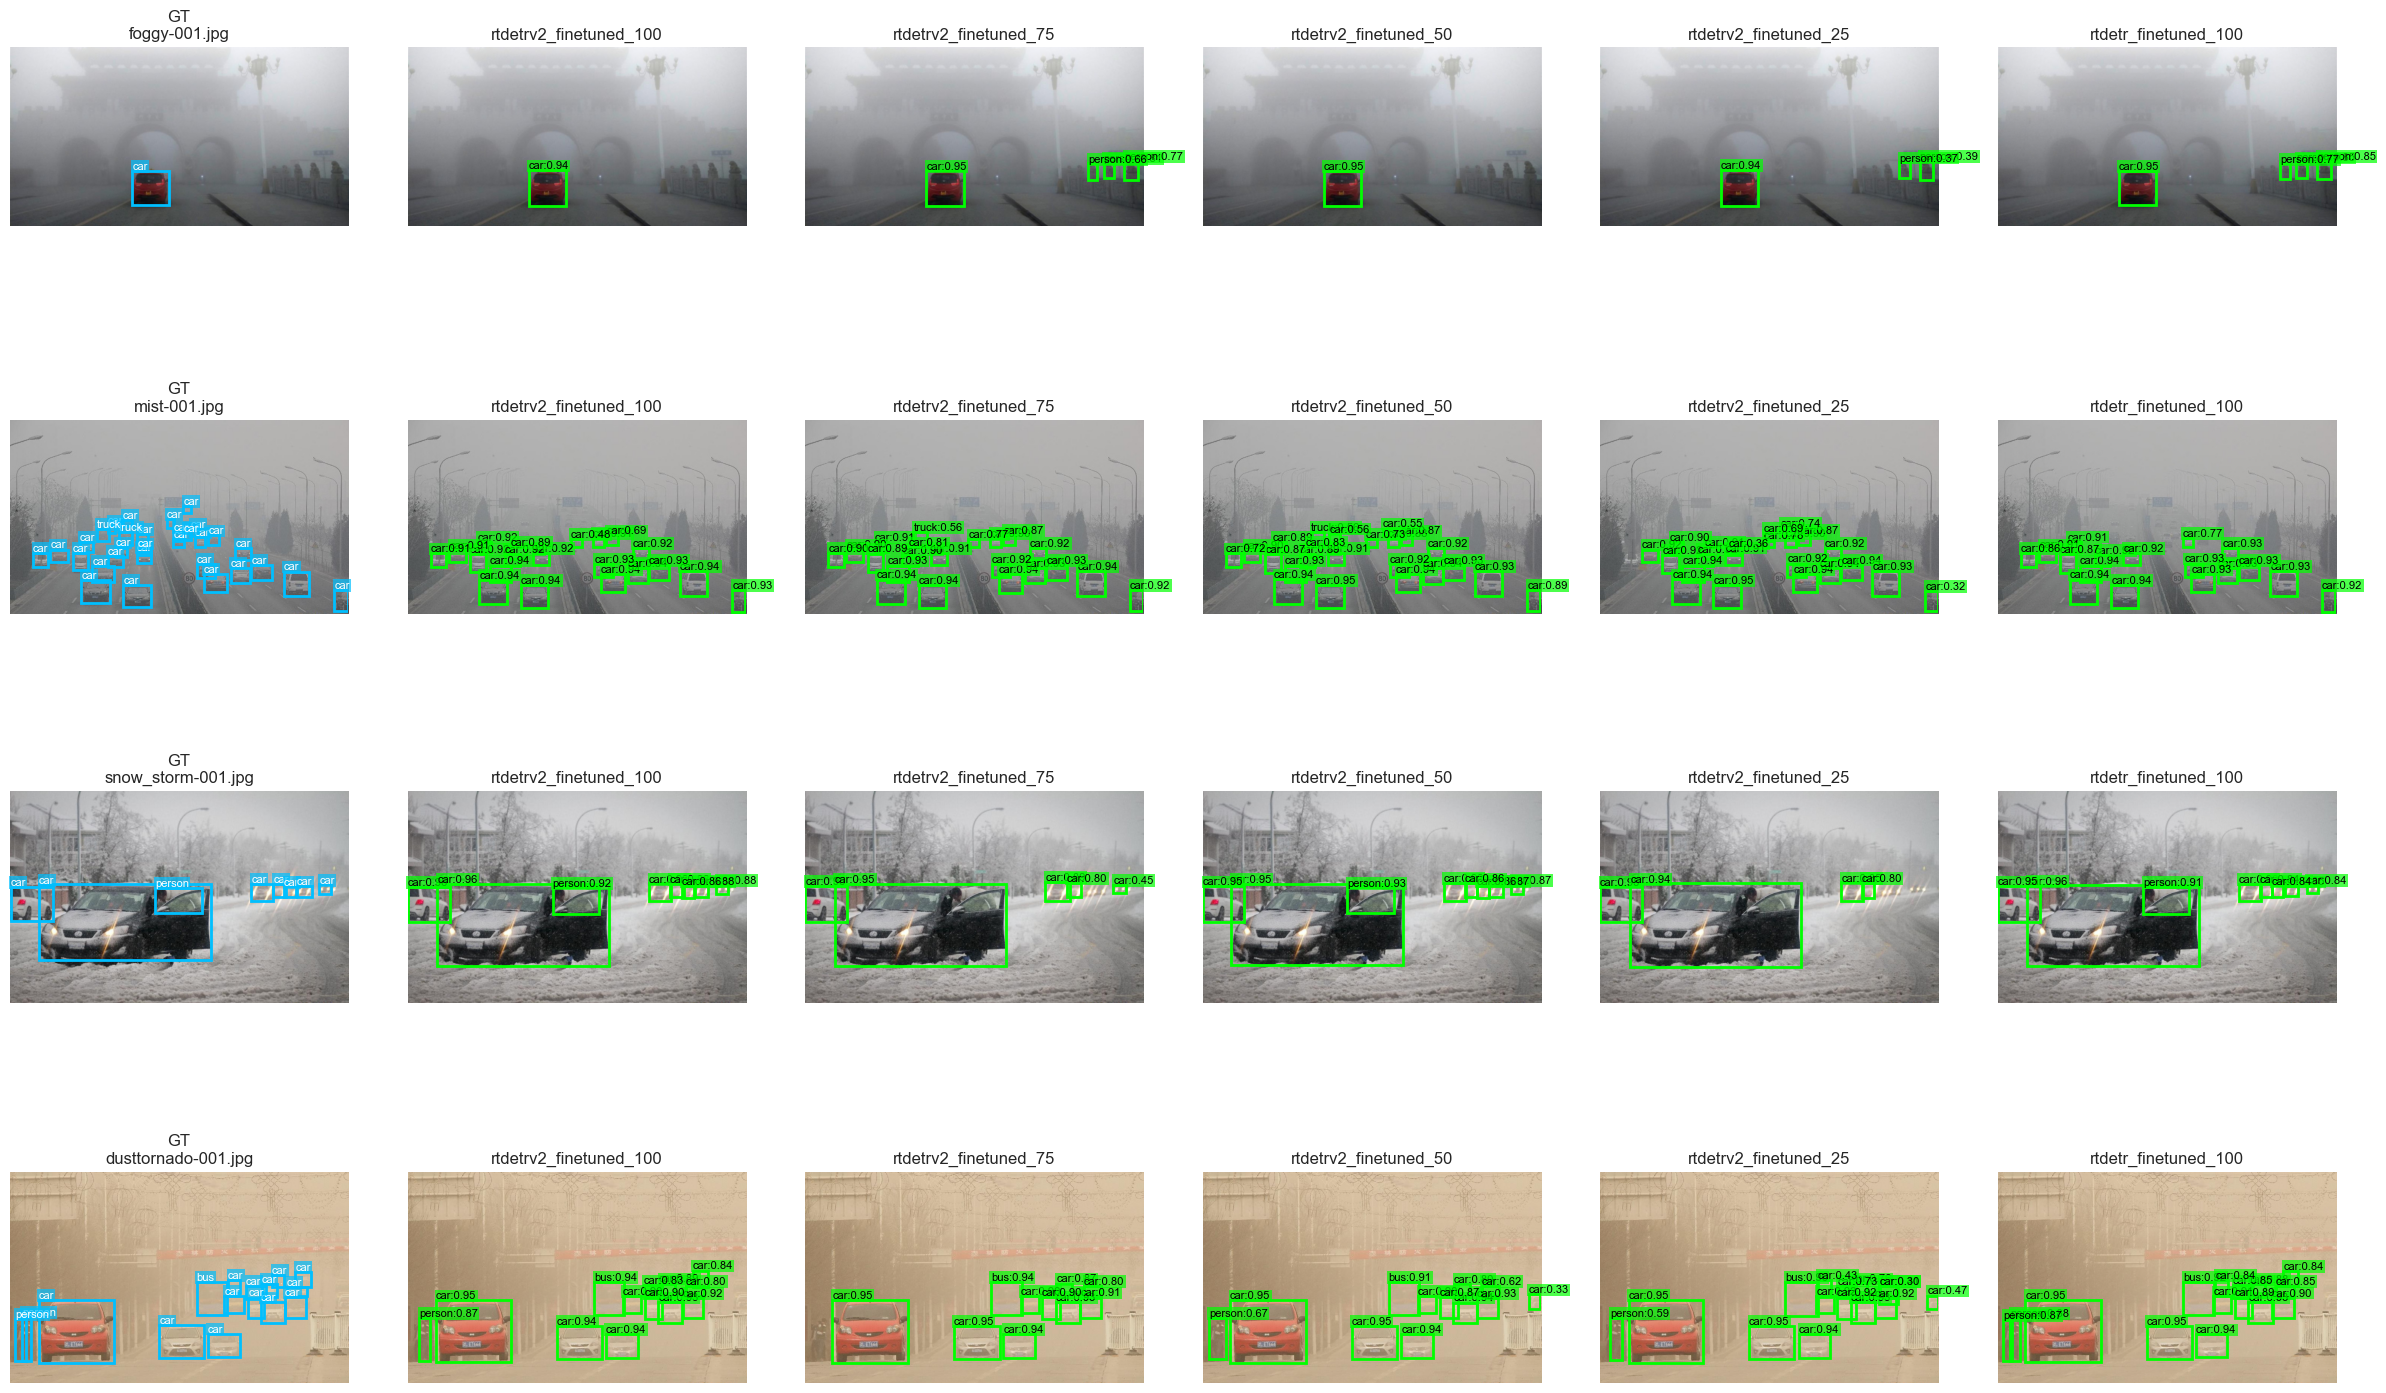

In [ ]:
def draw_ground_truth(ax, sample):
    image = Image.open(sample["image_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(f"GT\n{sample['file_name']}")
    ax.axis("off")

    target = parse_yolo_target(sample["label_path"], image.size, CLASS_MAPPING, image_name=sample["file_name"])
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="deepskyblue", facecolor="none")
        ax.add_patch(rect)
        ax.text(
            x1,
            max(0, y1 - 4),
            COCO_NAME_MAP.get(int(label), str(int(label))),
            color="white",
            fontsize=8,
            bbox=dict(facecolor="deepskyblue", alpha=0.7, pad=1, edgecolor="none"),
        )


def draw_prediction(ax, sample, pred, model_name):
    image = Image.open(sample["image_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(model_name)
    ax.axis("off")

    if pred is None:
        return

    mask = pred["scores"] >= SCORE_THRESHOLD
    boxes = pred["boxes"][mask]
    scores = pred["scores"][mask]
    labels = pred["labels"][mask]

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(
            x1,
            max(0, y1 - 4),
            f"{COCO_NAME_MAP.get(int(label), str(int(label)))}:{float(score):.2f}",
            color="black",
            fontsize=8,
            bbox=dict(facecolor="lime", alpha=0.7, pad=1, edgecolor="none"),
        )


n_rows = len(VISUAL_SAMPLES)
n_cols = 1 + len(MODEL_DIRS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

if n_rows == 1:
    axes = np.array([axes])

for row_idx, sample in enumerate(VISUAL_SAMPLES):
    draw_ground_truth(axes[row_idx, 0], sample)
    for col_idx, model_name in enumerate(MODEL_DIRS.keys(), start=1):
        pred = all_visual_predictions.get(model_name, {}).get(sample["file_name"])
        draw_prediction(axes[row_idx, col_idx], sample, pred, model_name)

plt.tight_layout()
plt.show()